# QLoRA Fine-tuning

## 1. Установка зависимостей

In [24]:
!pip -q install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip -q install trl datasets accelerate peft bitsandbytes transformers sentencepiece evaluate matplotlib pandas
!pip -q install lm-eval

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [26]:
import os
import re
import json
import time
import random
import gc
import warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from unsloth import FastLanguageModel
from unsloth import UnslothTrainer, UnslothTrainingArguments
from datasets import load_dataset
from trl import SFTTrainer, SFTConfig
from transformers import EarlyStoppingCallback

warnings.simplefilter('ignore')

In [6]:
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [7]:
def cuda_mem(label=""):
    if not torch.cuda.is_available():
        print("CUDA not available")
        return
    torch.cuda.synchronize()
    allocated = torch.cuda.memory_allocated() / 1024**2
    reserved = torch.cuda.memory_reserved() / 1024**2
    max_alloc = torch.cuda.max_memory_allocated() / 1024**2
    print(f"[VRAM] {label} allocated={allocated:.0f} MB | reserved={reserved:.0f} MB | max_alloc={max_alloc:.0f} MB")

In [8]:
def reset_cuda_peak():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

set_seed(SEED)

## 2. Выбор датасета и модели

### 2.1 Конфигурация

In [9]:
MODEL_NAME = "unsloth/Qwen3-0.6B"
DATASET_NAME = "IlyaGusev/saiga_scored"

### 2.2 Обоснование выбора модели

Модель: `unsloth/Qwen3-0.6B` (Qwen3 на 0.6B параметров)

- 0.6B параметров — минимальный размер, при котором модель может следовать инструкциям на русском языке. Умещается в GPU с 4-bit квантованием (~0.5 ГБ VRAM на веса + ~1 ГБ активации).
- Qwen3 обучен на многоязычном корпусе, включающем русскоязычные тексты.
- Unsloth обеспечивает оптимизированное 4-bit QLoRA (NF4) и ускоренный инференс через flash-attention.
- Модель поддерживает `apply_chat_template` с ролями system/user/assistant, что упрощает форматирование данных.

### 2.3 Обоснование выбора датасета

Датасет: `IlyaGusev/saiga_scored` — набор русскоязычных диалогов в формате system/user/assistant с оценкой качества (`score`).

- На русском языке.
- около 6 000 русскоязычных примеров после фильтрации.

In [10]:
MAX_SEQ_LENGTH = 2048
PACKING = True

## 3. Тестовая «корзинка» и загрузка модели

Собираем "корзинку" из 5 разноплановых тестовых примеров (стихи, JSON, фактология, роль, творчество) для визуальной оценки до обучения

In [11]:
prompts_for_test = [
    'Напиши короткое стихотворение о том, как нейросеть пытается уснуть, в стиле Сергея Есенина.',
    'Составь рецепт приготовления яичницы. Выведи результат СТРОГО в формате JSON с полями: "ingredients" (список) и "steps" (список шагов). Без лишнего текста.',
    'Объясни, что такое черная дыра, ровно в трех предложениях. Не пиши больше.',
    'Действуй как очень строгий и недовольный HR-менеджер. Напиши отказ кандидату на вакансию джун-разработчика.',
    'Придумай название для фантастического романа, напиши к нему логлайн в одно предложение и составь план из трех глав.'
]

In [13]:
reset_cuda_peak()
cuda_mem("start")

[VRAM] start allocated=8 MB | reserved=22 MB | max_alloc=8 MB


In [27]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=True, # включение квантования базовой модели
)
cuda_mem("after model load (4bit)")

==((====))==  Unsloth 2026.5.2: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
[VRAM] after model load (4bit) allocated=1232 MB | reserved=1276 MB | max_alloc=1248 MB


In [15]:
FastLanguageModel.for_inference(model)

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 1024, padding_idx=151669)
    (layers): ModuleList(
      (0): Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=1024, out_features=2048, bias=False)
          (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear4bit(in_features=1024, out_features=3072, bias=False)
          (up_proj): Linear4bit(in_features=1024, out_features=3072, bias=False)
          (down_proj): Linear4bit(in_features=3072, out_features=1024, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_lay

In [16]:
def generate_chat(model, tokenizer, user_text, system_text="Ты — полезный русскоязычный ассистент.", max_new_tokens=250):
    messages = [
        {"role": "system", "content": system_text},
        {"role": "user", "content": user_text},
    ]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True,
        enable_thinking=False  # ← не давать модели начинать с <think>
    )
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.eos_token_id,
        )
    generated_ids = out[0][inputs['input_ids'].shape[1]:]
    text = tokenizer.decode(generated_ids, skip_special_tokens=False)
    text = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL)
    text = re.sub(r'<\|im_start\|>\w*\n?|<\|im_end\|>', '', text).strip()
    return text

## 4. Предварительная оценка качества (до дообучения)

### 4.1 Генерация «корзинки» до обучения

In [17]:
print("\n" + "="*50 + " ГЕНЕРАЦИЯ ДО ОБУЧЕНИЯ " + "="*50)
for p in prompts_for_test:
    print(f"[ЗАПРОС]: {p}")
    ans = generate_chat(model, tokenizer, p)
    print(f"[ОТВЕТ]: {ans[:500]}...\n")
    print("-"*100)


================================================== ГЕНЕРАЦИЯ ДО ОБУЧЕНИЯ ==================================================
[ЗАПРОС]: Напиши короткое стихотворение о том, как нейросеть пытается уснуть, в стиле Сергея Есенина.


Both `max_new_tokens` (=250) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=250) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[ОТВЕТ]: Сергей Есенин:  
Нейросети уснет, и счастливо —  
Прыжки по космосу, и мечты в тонкости.  
Учителя и души — в голове, но не в земной.  
Тогда мир по-прежнему, но с новыми танцами....

----------------------------------------------------------------------------------------------------
[ЗАПРОС]: Составь рецепт приготовления яичницы. Выведи результат СТРОГО в формате JSON с полями: "ingredients" (список) и "steps" (список шагов). Без лишнего текста.


Both `max_new_tokens` (=250) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[ОТВЕТ]: ```json
{
  "ingredients": ["яичка", "мяко", "вода"],
  "steps": [
    "1. Промочите яички до выделения желтка.",
    "2. Добавьте мясо и воду в емкость.",
    "3. Кипните на водяной гонке.",
    "4. Накройте крышку и оставьте на 15 минут.",
    "5. Снимите, чтобы измельчить яичницу.",
    "6. Сушите яичницу на гребне или в воде.",
    "7. Выберите подходящую форму для десерт."
  ]
}
```...

----------------------------------------------------------------------------------------------------
[ЗАПРОС]: Объясни, что такое черная дыра, ровно в трех предложениях. Не пиши больше.


Both `max_new_tokens` (=250) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[ОТВЕТ]: Черная дыра — это гипотеза, предполагаемая в теории гравитационного течения, которая может привести к разрыву пространства-времени и создать эффект "пупергравитации". Это космологическая модель, подтверждающая существование виртуальной вселенной....

----------------------------------------------------------------------------------------------------
[ЗАПРОС]: Действуй как очень строгий и недовольный HR-менеджер. Напиши отказ кандидату на вакансию джун-разработчика.


Both `max_new_tokens` (=250) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[ОТВЕТ]: Конечно, вот пример текста, который выглядит как если вы являетесь строгим и недовольным HR-менеджером:

---

**Однако, я не могу пройти через этот процесс. Судя по вашему обращению, вы не удовлетворены.**

Если вы не хотите быть работать, то лучше сначала уточните требования, а затем пожалуйста, обратитесь к нашей команде для более детального обсуждения. 

Нам нужно подтвердить, что в нашем случае не удовлетворены. Если у вас есть конкретные вопросы или запросы, можно предоставить более детальн...

----------------------------------------------------------------------------------------------------
[ЗАПРОС]: Придумай название для фантастического романа, напиши к нему логлайн в одно предложение и составь план из трех глав.
[ОТВЕТ]: **Название:** *Слой магических туманов*

**Логоплан:**  
"В мире, где свет не сияет, а лишь непрозрачность — мир, где все тьмы становятся легендами."  

**План:**  
1. **История, как магические туманы взаимодействуют с реалью**, чтобы оставить след н

### 4.2 Оценка на lm-evaluation-harness (до обучения)

In [18]:
BASE_BENCH_DIR = "/content/bench_base"
os.makedirs(BASE_BENCH_DIR, exist_ok=True)

!lm_eval \
  --model hf \
  --model_args pretrained={MODEL_NAME},trust_remote_code=True \
  --tasks truthfulqa_mc2 \
  --device cuda:0 \
  --batch_size 8 \
  --limit 50 \
  --output_path {BASE_BENCH_DIR}/truthfulqa_base.json

2026-05-15:10:03:16 WARNING  [config.evaluate_config:287] --limit SHOULD ONLY BE USED FOR TESTING. REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2026-05-15:10:03:28 INFO     [_cli.run:388] Selected Tasks: ['truthfulqa_mc2']
2026-05-15:10:03:28 INFO     [evaluator:214] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2026-05-15:10:03:28 INFO     [evaluator:239] Initializing hf model, with arguments: {'pretrained': 'unsloth/Qwen3-0.6B', 'trust_remote_code': True}
2026-05-15:10:03:33 INFO     [models.huggingface:286] Using device 'cuda:0'
config.json: 100%|█████████████████████████████| 752/752 [00:00<00:00, 3.09MB/s]
tokenizer_config.json: 10.5kB [00:00, 17.4MB/s]
vocab.json: 2.78MB [00:00, 50.8MB/s]
merges.txt: 1.67MB [00:00, 112MB/s]
tokenizer.json: 100%|██████████████████████| 11.4M/11.4M [00:00<00:00, 24.1MB/s]
special_tokens_map.json: 100%|█████████████████| 614/614 [00:00<00:00, 4.50MB/s]
chat_templat

## 5. Загрузка и анализ датасета

In [19]:
ds = load_dataset(DATASET_NAME)
print("Структура датасета:", ds)

README.md:   0%|          | 0.00/772 [00:00<?, ?B/s]

train.parquet:   0%|          | 0.00/115M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/41609 [00:00<?, ? examples/s]

Структура датасета: DatasetDict({
    train: Dataset({
        features: ['messages', 'source', 'opus_score', 'language', 'turns', 'sonnet_topic', 'sonnet_topic_explanation', 'sonnet_complexity', 'sonnet_complexity_explanation', 'is_bad_by_regex', 'score_explanation'],
        num_rows: 41609
    })
})


### 5.1 EDA: распределение оценок и длин

In [20]:
def format_text(example):
    conversation = example.get("messages", [])
    if not isinstance(conversation, list):
        conversation = [conversation]

    user = next(
    (msg.get("content", "") for msg in conversation
     if isinstance(msg, dict) and msg.get("role") in ("user", "human")),
    ""
)
    assistant = next(
    (msg.get("content", "") for msg in conversation
     if isinstance(msg, dict) and msg.get("role") in ("assistant", "bot")),
    ""
)
    if len(assistant.strip()) < 20:   # фильтруем пустые и слишком короткие
        return {"text": None, "messages_norm": []}

    messages = [
        {"role": "system", "content": "Ты — полезный русскоязычный ассистент, который умеет красиво и грамотно генерировать тексты."},
        {"role": "user", "content": user},
        {"role": "assistant", "content": assistant},
    ]
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False,
        enable_thinking=False   # ← убирает <think> из обучающих примеров
    )
    return {"text": text, "messages_norm": messages}

In [21]:
raw_ru = ds['train'].filter(lambda x: x.get('language') == 'Russian')
ex = raw_ru[0]
print("Тип messages:", type(ex['messages']))
print("Содержимое:")
for m in ex['messages']:
    role = m.get('role', '???')
    content = m.get('content', '???')
    print(f"  [{role}]: {repr(content[:100])}")

Filter:   0%|          | 0/41609 [00:00<?, ? examples/s]

Тип messages: <class 'list'>
Содержимое:
  [user]: 'Распиши словами данные-Русский язык\nНадежность либо взаимопомощь и простота в общении, товарищество-'
  [bot]: 'В данном тексте представлены различные аспекты и качества межличностных отношений, каждому из которы'


In [22]:
raw = ds['train'].filter(lambda x: x.get('language') == 'Russian')
raw = raw.shuffle(seed=SEED).select(range(min(6000, len(raw))))
raw2 = raw.map(format_text, remove_columns=raw.column_names)
raw2 = raw2.filter(lambda x: x['text'] is not None)
print(f"Итого примеров: {len(raw2)}")
print(raw2[0]['text'][:400])

Filter:   0%|          | 0/41609 [00:00<?, ? examples/s]

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/6000 [00:00<?, ? examples/s]

Итого примеров: 5898
<|im_start|>system
Ты — полезный русскоязычный ассистент, который умеет красиво и грамотно генерировать тексты.<|im_end|>
<|im_start|>user
<|im_end|>
<|im_start|>assistant
<think>

</think>

Привет! Как ты сегодня? Уже написал письмо со своими новогодними желаниями?<|im_end|>



In [25]:
# Проверка качества данных
for i in range(3):
    print(f"--- Пример {i} ---")
    print(raw2[i]['text'][:400])
    print()

--- Пример 0 ---
<|im_start|>system
Ты — полезный русскоязычный ассистент, который умеет красиво и грамотно генерировать тексты.<|im_end|>
<|im_start|>user
<|im_end|>
<|im_start|>assistant
<think>

</think>

Привет! Как ты сегодня? Уже написал письмо со своими новогодними желаниями?<|im_end|>


--- Пример 1 ---
<|im_start|>system
Ты — полезный русскоязычный ассистент, который умеет красиво и грамотно генерировать тексты.<|im_end|>
<|im_start|>user
Я купила браслет в магазине б/у, но не могу определить, что это за марка. Может быть, ты сможешь мне помочь?<|im_end|>
<|im_start|>assistant
<think>

</think>

Конечно, я могу постараться помочь. Могу предложить несколько типичных способов определить марку брас

--- Пример 2 ---
<|im_start|>system
Ты — полезный русскоязычный ассистент, который умеет красиво и грамотно генерировать тексты.<|im_end|>
<|im_start|>user
Заканчиваю магистратуру, параллельно работаю программистом. Надо писать диссертацию. Через 4 месяца защита. Но в целом не особо п

In [26]:
print("\nПример формата для обучения:")
print(raw2[0]["text"][:600])


Пример формата для обучения:
<|im_start|>system
Ты — полезный русскоязычный ассистент, который умеет красиво и грамотно генерировать тексты.<|im_end|>
<|im_start|>user
<|im_end|>
<|im_start|>assistant
<think>

</think>

Привет! Как ты сегодня? Уже написал письмо со своими новогодними желаниями?<|im_end|>



In [27]:
dataset = raw2.train_test_split(test_size=0.02, seed=SEED)

In [28]:
def token_len(text):
    return len(tokenizer(text, add_special_tokens=False).input_ids)

In [29]:
lens = [token_len(x) for x in dataset["train"]["text"][:2000]]
print("\nСтатистика по длине токенов:")
print(pd.Series(lens).describe(percentiles=[0.5,0.9,0.95,0.99]).to_dict())


Статистика по длине токенов:
{'count': 2000.0, 'mean': 595.3555, 'std': 707.044494411978, 'min': 62.0, '50%': 523.0, '90%': 989.2000000000003, '95%': 1246.7499999999993, '99%': 2493.6199999999994, 'max': 21897.0}


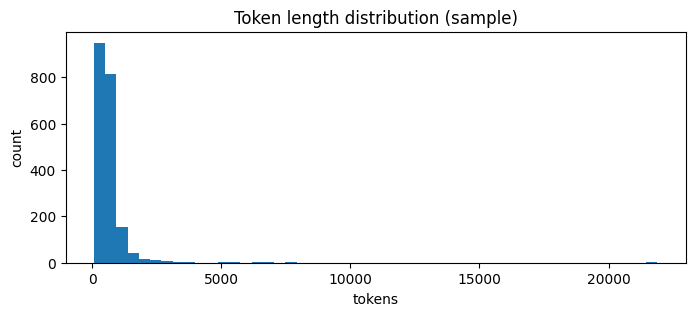

In [30]:
plt.figure(figsize=(8,3))
plt.hist(lens, bins=50)
plt.title("Token length distribution (sample)")
plt.xlabel("tokens"); plt.ylabel("count")
plt.show()

## 6. QLoRA-дообучение

### 6.1 Обоснование гиперпараметров QLoRA

| Параметр | Значение | Обоснование |
|---|---|---|
| `r` | 16 | Ранг матриц LoRA. r=8 — слишком мало для русского (мало ёмкости), r=32 — вдвое дороже по памяти. |
| `lora_alpha` | 32 | Коффициент масштабирования. Отношение alpha/r = 2.0 — хорошо  для SFT. При alpha=r масштабирование 1:1, при alpha=2r веса адаптера имеют вдвое больший вклад. |
| `lora_dropout` | 0.0 | Отключён — при малом числе шагов (200) dropout снижает обучающий сигнал и не даёт защиты от переобучения. |
| `target_modules` | attn + MLP | Захватываем q/k/v/o_proj (внимание) и gate/up/down_proj (MLP). Только attn даёт меньше параметров, но медленнее адаптирует знания. |
| `load_in_4bit` | True | NF4-квантование базовой модели = QLoRA. Снижает VRAM с ~1.2 ГБ до ~0.5 ГБ. |
| `learning_rate` | 2e-4 | Подходит для LoRA-SFT |
| `max_steps` | 200 | ~200 шагов при batch 16 (4×4 grad_accum) = ~3200 примеров. |
| `optim` | paged_adamw_8bit | 8-bit paged AdamW уменьшает память под оптимайзер в 4 раза. |

In [31]:
def add_lora(model, r=16, lora_alpha=32, target="attn_mlp", dropout=0.0):
    """
    Настройка QLoRA адаптеров.
    """
    if target == "attn":
        target_modules = ["q_proj","k_proj","v_proj","o_proj"]
    else:
        # меняем не только внимание (attn), но и MLP-слои (gate, up, down).
        target_modules = ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"]

    model = FastLanguageModel.get_peft_model(
        model,
        r=r,                    # Ранг матрицы LoRA = 16
        lora_alpha=lora_alpha,  # Шкалирование. Отношение alpha/r = 32/16 = 2
        lora_dropout=dropout,   # Dropout = 0.0
        bias="none",
        target_modules=target_modules,
        use_gradient_checkpointing=True,  # скорость для QLoRA
        random_state=SEED,
        use_rslora=False,
    )
    return model, target_modules

def trainable_params_report(model):
    trainable = 0
    total = 0
    for p in model.parameters():
        n = p.numel()
        total += n
        if p.requires_grad:
            trainable += n
    return {"trainable": trainable, "total": total, "trainable_pct": 100*trainable/total}

In [32]:
# Перезагружаем модель
del model
gc.collect()
torch.cuda.empty_cache()
reset_cuda_peak()

In [33]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = None,
    load_in_4bit = True,
)

==((====))==  Unsloth 2026.5.2: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [34]:
# Настраиваем настоящие токены
tokenizer.pad_token = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id
model.config.pad_token_id = tokenizer.pad_token_id
if getattr(model, "generation_config", None) is not None:
    model.generation_config.pad_token_id = tokenizer.pad_token_id

In [35]:
# Вешаем LoRA
model, target_modules = add_lora(model, r=16, lora_alpha=32, target="attn_mlp", dropout=0.0)

steps = 200

Unsloth 2026.5.2 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


In [36]:
args = UnslothTrainingArguments(
    output_dir="sft_runs/saiga_main",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    warmup_steps=int(steps * 0.1),
    max_steps=steps,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=20,
    save_strategy="steps",
    save_steps=20,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    optim="paged_adamw_8bit",
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    report_to="none",
    seed=SEED,
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    packing=False,
)


In [37]:
# ДИАГНОСТИКА — перед созданием SFTTrainer
print("tokenizer.eos_token:    ", repr(tokenizer.eos_token))
print("tokenizer.eos_token_id: ", tokenizer.eos_token_id)
print("tokenizer.pad_token:    ", repr(tokenizer.pad_token))
print("args.eos_token:         ", repr(args.eos_token))

tokenizer.eos_token:     '<|im_end|>'
tokenizer.eos_token_id:  151645
tokenizer.pad_token:     '<|im_end|>'
args.eos_token:          None


In [38]:
# Создаем тренера
trainer = UnslothTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    args=args,
)

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/5780 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/118 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


In [39]:
trainer.add_callback(EarlyStoppingCallback(early_stopping_patience=2))

In [40]:
cuda_mem("before train")
t0 = time.time()
trainer.train()
t1 = time.time()
cuda_mem("after train")
print("train time (min):", (t1 - t0) / 60)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


[VRAM] before train allocated=1266 MB | reserved=1326 MB | max_alloc=1267 MB


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 5,780 | Num Epochs = 1 | Total steps = 200
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 10,092,544 of 606,142,464 (1.67% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
20,1.602351,1.500612
40,1.423399,1.439874
60,1.415470,1.422633
80,1.405748,1.412933
100,1.385992,1.406562
120,1.322469,1.401128
140,1.345399,1.397781
160,1.419945,1.394314
180,1.379757,1.392068
200,1.358568,1.391168


Unsloth: Restored added_tokens_decoder metadata in sft_runs/saiga_main/checkpoint-20/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in sft_runs/saiga_main/checkpoint-40/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in sft_runs/saiga_main/checkpoint-60/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in sft_runs/saiga_main/checkpoint-80/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in sft_runs/saiga_main/checkpoint-100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in sft_runs/saiga_main/checkpoint-120/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in sft_runs/saiga_main/checkpoint-140/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in sft_runs/saiga_main/checkpoint-160/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in sft_runs/saiga_main/checkpoint-180/tokenizer_config.json.
Unsloth: Restored added

[VRAM] after train allocated=1295 MB | reserved=1418 MB | max_alloc=10902 MB
train time (min): 56.65948881705602


## 7. Оценка качества после дообучения

### 7.1 Генерация «корзинки» после обучения

In [41]:
FastLanguageModel.for_inference(trainer.model)

print("\n" + "="*50 + " ГЕНЕРАЦИЯ ПОСЛЕ QLoRA " + "="*50)
for p in prompts_for_test:
    print(f"[ЗАПРОС]: {p}")
    ans = generate_chat(trainer.model, tokenizer, p)
    print(f"[ОТВЕТ]: {ans[:500]}...\n")
    print("-"*100)

Both `max_new_tokens` (=250) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



================================================== ГЕНЕРАЦИЯ ПОСЛЕ QLoRA ==================================================
[ЗАПРОС]: Напиши короткое стихотворение о том, как нейросеть пытается уснуть, в стиле Сергея Есенина.


Both `max_new_tokens` (=250) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[ОТВЕТ]: Сергей Есенин вдохновляет на умные будущее:

"Колеса, которые не заблудились в утренней мгла,
Помнишь, что мы умеем искать свет.
Каждый день, когда в сон спит,
Ты посвящаешься своей жизни.

Самая тайна твоего сна —
Слушай, я знаю, как ты хочешь.
Стоит ли тебе еще один день?...

----------------------------------------------------------------------------------------------------
[ЗАПРОС]: Составь рецепт приготовления яичницы. Выведи результат СТРОГО в формате JSON с полями: "ingredients" (список) и "steps" (список шагов). Без лишнего текста.


Both `max_new_tokens` (=250) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[ОТВЕТ]: ```json
{
  "ingredients": [
    "2 яйца",
    "1 столовая ложка кулинарной муки",
    "1/4 стакана яблочного сока",
    "1 чайная ложка перекусанного меда",
    "2 столовые ложки растительного масла",
    "1/2 чайной ложки корицы"
  ],
  "steps": [
    "Взять 2 яйца и обсушить их сухими ладонями.",
    "Налить в бленер посыпать 1 столовую ложку кулинарной муки.",
    "Приложить на среднем овощном партичке.",
    "Потом добавить 1/4 стакана яблочного сока, 1 чайную ложку перекусанного меда и 2 с...

----------------------------------------------------------------------------------------------------
[ЗАПРОС]: Объясни, что такое черная дыра, ровно в трех предложениях. Не пиши больше.


Both `max_new_tokens` (=250) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[ОТВЕТ]: Черная дыра — это гиперболическое понятие, которое описывает когнитивную непротиворечивость. Это не просто тень или зеркало, а символ изображения конфликтного состояния. Эта идея объясняет, как мы должны понять и оценивать сложные вопросы и ситуации. Черная дыра помогает нам увидеть, что иногда можно сомневаться, но это не значит, что мы должны полностью верить в то, что мы считаем. Она показывает, что даже если мы не уверены, мы можем найти свою позицию и находить способы разрешать конфликты....

----------------------------------------------------------------------------------------------------
[ЗАПРОС]: Действуй как очень строгий и недовольный HR-менеджер. Напиши отказ кандидату на вакансию джун-разработчика.


Both `max_new_tokens` (=250) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[ОТВЕТ]: Здравствуйте, [Имя Кандидата]. Я действительно не могу удивиться вашим выбором в этой вакансии, но я не могу позволить, чтобы вы могли работать с нами.

Мы знаем, что каждый вакантант имеет свои особенности, и мы не можем позволить, чтобы вы оставались с нами без опыта и навыков в области программирования. 

Для начала, я должен рассказать вам, что мы работаем с другими компаниями и мы хотим работать с людьми, которые имеют опыт в этом деле. Мы работаем в команде, которая стремится к успеху и мы...

----------------------------------------------------------------------------------------------------
[ЗАПРОС]: Придумай название для фантастического романа, напиши к нему логлайн в одно предложение и составь план из трех глав.
[ОТВЕТ]: "Солнечный пик - 2014: Дракон и тварь, которые светят"....

----------------------------------------------------------------------------------------------------


In [42]:
# Сохраняем адаптер временно для оценки через lm-eval
ADAPTER_DIR = "/content/artifacts/adapter_storytelling"
os.makedirs(ADAPTER_DIR, exist_ok=True)
trainer.model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

Unsloth: Restored added_tokens_decoder metadata in /content/artifacts/adapter_storytelling/tokenizer_config.json.


('/content/artifacts/adapter_storytelling/tokenizer_config.json',
 '/content/artifacts/adapter_storytelling/chat_template.jinja',
 '/content/artifacts/adapter_storytelling/tokenizer.json')

### 7.3 Бенчмарк lm-evaluation-harness после дообучения

In [43]:
SFT_BENCH_DIR = "/content/bench_sft"
os.makedirs(SFT_BENCH_DIR, exist_ok=True)

In [44]:
!lm_eval \
  --model hf \
  --model_args pretrained={MODEL_NAME},peft={ADAPTER_DIR},trust_remote_code=True \
  --tasks truthfulqa_mc2 \
  --device cuda:0 \
  --batch_size 8 \
  --limit 50 \
  --output_path {SFT_BENCH_DIR}/truthfulqa_sft.json

2026-05-15:11:02:58 WARNING  [config.evaluate_config:287] --limit SHOULD ONLY BE USED FOR TESTING. REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2026-05-15:11:03:10 INFO     [_cli.run:388] Selected Tasks: ['truthfulqa_mc2']
2026-05-15:11:03:10 INFO     [evaluator:214] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2026-05-15:11:03:10 INFO     [evaluator:239] Initializing hf model, with arguments: {'pretrained': 'unsloth/Qwen3-0.6B', 'peft': '/content/artifacts/adapter_storytelling', 'trust_remote_code': True}
2026-05-15:11:03:15 INFO     [models.huggingface:286] Using device 'cuda:0'
2026-05-15:11:03:16 INFO     [models.huggingface:579] Model parallel was set to False, max memory was not set, and device map was set to {'': 'cuda:0'}
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading weights: 100%|███████████████████████| 3

In [45]:
def read_lm_eval(path):
    with open(path, "r", encoding="utf-8") as f:
        j = json.load(f)
    return j.get("results", {})

In [46]:
base_files = sorted([f for f in os.listdir(BASE_BENCH_DIR) if f.endswith('.json')])
sft_files = sorted([f for f in os.listdir(SFT_BENCH_DIR) if f.endswith('.json')])

In [47]:
base_path = os.path.join(BASE_BENCH_DIR, base_files[-1])
sft_path = os.path.join(SFT_BENCH_DIR, sft_files[-1])

In [48]:
base_res = read_lm_eval(base_path)
sft_res = read_lm_eval(sft_path)

In [49]:
task = "truthfulqa_mc2"
print("BASE:", base_res.get(task, {}))
print("SFT:", sft_res.get(task, {}))

BASE: {'name': 'truthfulqa_mc2', 'alias': 'truthfulqa_mc2', 'sample_len': 50, 'acc,none': 0.4368451776831864, 'acc_stderr,none': 0.05805210486117057}
SFT: {'name': 'truthfulqa_mc2', 'alias': 'truthfulqa_mc2', 'sample_len': 50, 'acc,none': 0.48408790000278523, 'acc_stderr,none': 0.06094856045497932}


In [50]:
if task in base_res and task in sft_res:
    delta = {k: sft_res[task].get(k, 0) - base_res[task].get(k, 0)
             for k in sft_res[task].keys() if isinstance(sft_res[task].get(k), (int,float)) and k in base_res[task]}
    print("\nDelta (Изменение):", delta)


Delta (Изменение): {'sample_len': 0, 'acc,none': 0.04724272231959881, 'acc_stderr,none': 0.0028964555938087444}


In [ ]:
MERGED_DIR = "/content/artifacts/merged_storytelling_16bit"
os.makedirs(MERGED_DIR, exist_ok=True)

trainer.model.save_pretrained_merged(MERGED_DIR, tokenizer, save_method="merged_16bit")
print(f"Модель сохранена в {MERGED_DIR}")

config.json:   0%|          | 0.00/752 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /content/artifacts/merged_storytelling_16bit/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

**Корзинка:** разбор по промптам
- Промпт 1 — стихотворение в стиле Есенина

До: четыре строки, формально похожи на стихи, но бессмысленные («Прыжки по космосу», «души в голове»). Нет ни есенинской образности, ни ритма.

После: появилась попытка строфической структуры и обращения («Слушай, я знаю, как ты хочешь»), но содержательно всё ещё требует улучшений.

- Промпт 2 — JSON-рецепт яичницы

До: формат JSON соблюдён, но части абсурдные («мяко», «вода»), шаги бессвязные («сушите на гребне»).

После: JSON по-прежнему соблюдён, части стали реалистичнее по форме («2 яйца», «растительное масло»), но состав всё равно нерелевантный (мёд, корица, яблочный сок в яичнице). Следование формату сохранилось.

- Промпт 3 — чёрная дыра в трёх предложениях

До: два предложения, упоминание «пупергравитации» — ненастоящего термина. Инструкцию «ровно три предложения» модель нарушила.

После: пять предложений вместо трёх, определение стало философским («когнитивная непротиворечивость») и полностью неверным физически. Регресс — модель стала хуже следовать ограничению по длине и утратила даже поверхностную связь с физикой.

- Промпт 4 — строгий HR-отказ

До: модель «сломала» роль — вместо отказа написала инструкцию самому кандидату.

После: появилась правильная структура письма (обращение, причина), модель удержала роль HR-менеджера до конца ответа.

- Промпт 5 — фантастический роман

До: название, логлайн и план из трёх глав — все три элемента присутствуют, структура соблюдена.

После: одна строка и структура полностью утеряна. Явный регресс — модель перестала следовать многоэлементной инструкции.